In [1]:
import zipfile
from google.colab import drive
import pathlib
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# get the unique conversation IDs from each zipped folder
def get_convo_ids():
  path = f'/content/drive/MyDrive/candor_raw/raw_media_part_{num:03d}.zip'

  with zipfile.ZipFile(path, 'r') as myzip:
    convo_ids = set() # recreate an empty set for each zipped dir

    # only take the outermost directories, and not any further nested ones
    for name in myzip.namelist():
      obj = pathlib.PurePosixPath(name)
      dir = obj.parts[0]

      if name.endswith('/') or len(obj.parts) > 1:
        convo_ids.add(dir)

  return path,convo_ids

# build dataframe with metadata to do some prior statistical analysis in order
# to ensure appropriate range for further analysis
def build_df(path, convo_ids):
  for cid in convo_ids:

    # extract metadata.json and survey.csv
    # then save as local vars to easily access
    with zipfile.ZipFile(path, 'r') as myzip:
      with myzip.open(f'{cid}/metadata.json', 'r') as file_stream:
        metadata = json.load(file_stream)
      with myzip.open(f'{cid}/survey.csv', 'r') as file_stream:
        survey = pd.read_csv(file_stream)

    # for each of the 2 speakers, extract their user_id and the channel (L or R)
    for speaker in metadata.get('speakers'):
      channel = speaker.get('channel')
      user_id = speaker.get('user_id')

      # using user ID, extract enjoyment rating from survey dataframe
      enjoyment = survey.loc[survey['user_id'] == user_id, 'how_enjoyable'].iloc[0]

      # check for NaN values due to survey incompletion; every other value is
      # guaranteed to be filled by the nature of CANDOR corpus
      if pd.isna(enjoyment):
        row = survey.loc[survey['user_id'] == user_id]
        total = row.shape[1]
        n_blank = row.isna().sum(axis=1).iloc[0]
        print(f'part {num:03d} / {cid} / {user_id}: {n_blank}/{total} fields blank')
        # prints for logging

      # inputs NaN value anyway; data cleanup will happen once df is fully built
      all_data.loc[len(all_data)] = [num, cid, user_id, channel, enjoyment]

In [3]:
all_data = pd.DataFrame(columns=['dir_num', 'convo_id', 'user_id', 'channel', 'enjoyment'])
"""
dir_num: the number associated with the zipped directories
  e.g raw_media_part_001, raw_media_part_002, ... raw_media_part_166

convo_id: the unique ID representing a dyadic conversation.

user_id: the unique ID representing each speaker.
  many speakers participated in more than one conversation, so user_id is a
  repeating value. convo_id will be used to distinguish the distinct conversations
  engaged in by one person, if more than one exists.

channel: whether this speaker was on the left or right side of the compiled
  conversational video. randomly assigned by CANDOR, and recorded to ensure
  consistency for asymmetry measurement.

enjoyment: the rating measuring how enjoyable the conversation was, left by each
  speaker. ranges from 1-9 on a Likert Scale (1 = not at all enjoyable, 9 =
  extremely enjoyable)
"""

df_path = '/content/drive/MyDrive/pioneer_data/all_data.csv'
if os.path.isfile(df_path):
  print('dataframe already exists')
  print('loading csv into dataframe...')
  all_data = pd.read_csv(df_path)
else:
  print('dataframe does not exist in drive')
  print('constructing df from candor corpus...')
  for num in range(1, 167):
    path, convo_ids = get_convo_ids()
    build_df(path, convo_ids)

print('dataframe complete!')
print(f'length: {len(all_data)}')
print(all_data['enjoyment'].value_counts())

dataframe already exists
loading csv into dataframe...
dataframe complete!
length: 3206
enjoyment
9.0    913
8.0    827
7.0    757
6.0    370
5.0    176
4.0     86
3.0     43
1.0     19
2.0     15
Name: count, dtype: int64


In [ ]:
# skippable if df is loaded from csv instead of constructed manually

len_before = len(all_data)
print(f'{len(all_data)} rows total')
print(f'{all_data['convo_id'].nunique()} unique conversations')
print(f'{all_data['user_id'].nunique()} unique speakers')

print(f'NaN values:')
print(all_data.isna().sum())

3312 rows total
1656 unique conversations
1456 unique speakers
NaN values:
dir_num       0
convo_id      0
user_id       0
channel       0
enjoyment    55
dtype: int64


In [ ]:
# skippable if df is loaded from csv instead of constructed manually

all_data = all_data.dropna(subset=['enjoyment'])

vcs = all_data['convo_id'].value_counts()
indices = vcs[vcs==2].index

all_data = all_data[all_data['convo_id'].isin(indices)].copy()

print(f'new number of rows: {len(all_data)}')
print(f'{len_before-len(all_data)} rows deleted total')
print(f'{all_data['convo_id'].nunique()} unique conversations')
print(f'{all_data['user_id'].nunique()} unique speakers')

all_data.to_csv('/content/drive/MyDrive/pioneer_data/all_data.csv', index=False)

new number of rows: 3206
106 rows deleted total
1603 unique conversations
1417 unique speakers


In [5]:
# add a new column: difference in enjoyment (left minus right)
# also skippable if df is loaded in

reshaped = all_data.pivot(index='convo_id', columns='channel', values='enjoyment')
reshaped['enjoy_diff'] = reshaped['L'] - reshaped['R']

all_data['enjoy_diff'] = all_data['convo_id'].map(reshaped['enjoy_diff'])

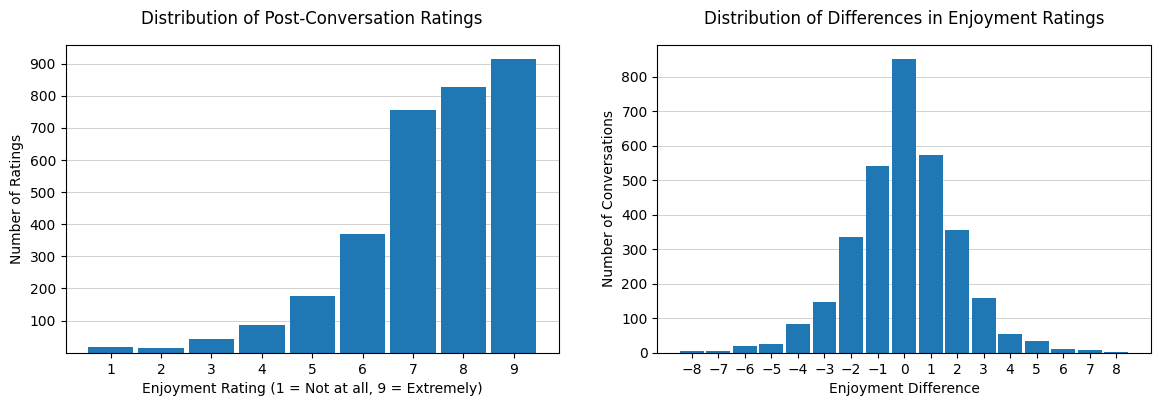

In [14]:
fix, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

ax[0].bar(x=enjoyment_vcs.index, height=enjoyment_vcs.values, width=0.9)
ax[0].set_title('Distribution of Post-Conversation Ratings', pad=15)
ax[0].set_xlabel('Enjoyment Rating (1 = Not at all, 9 = Extremely)')
ax[0].set_ylabel('Number of Ratings')

ax[0].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9])
ax[0].set_yticks([100, 200, 300, 400, 500, 600, 700, 800, 900])

ax[0].set_axisbelow(True)
ax[0].grid(color='gray', axis='y', linewidth=0.5, alpha=0.5)

ax[1].bar(diff_vcs.index, diff_vcs.values, width=0.9)

ax[1].set_title('Distribution of Differences in Enjoyment Ratings', pad=15)
ax[1].set_xlabel('Enjoyment Difference')
ax[1].set_ylabel('Number of Conversations')

ax[1].set_xticks(range(-8, 9))

ax[1].set_axisbelow(True)
ax[1].grid(color='gray', axis='y', linewidth=0.5, alpha=0.5)


In [7]:
# threshold for asymmetry: abs(diff) >= threshold for it to be considered asymmetric
asym_thresh = 4
asym_convos = all_data[abs(all_data['enjoy_diff']) >= asym_thresh].copy()

print(f'number of conversations with asymmetry >= {asym_thresh}: {len(asym_convos)}')
print(f'number of unique speakers: {asym_convos["user_id"].nunique()}')

number of conversations with asymmetry >= 4: 246
number of unique speakers: 208
